In [1]:
pip install pydantic 

Note: you may need to restart the kernel to use updated packages.


In [2]:
# !pip uninstall -y langchain langchain-core langgraph langchain-groq

In [3]:
!pip install -U langchain langchain-core langgraph langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 15.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 11.5 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
  Attempting uninstall: langgraph-sdk
    Found existing installation: langgraph-sdk 0.3.13
    Uninstalling langgraph-sdk-0.3.13:
      Successfully uninstalled langgraph-sdk-0.3.13
  Attempting uninstall: langgraph-checkpoint
    Found existing inst

In [ ]:

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator
from langchain_groq import ChatGroq
import os


In [5]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [6]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [7]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

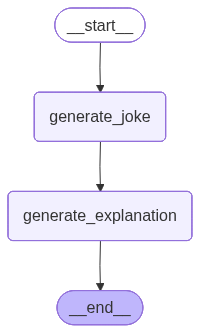

In [8]:
from langgraph.checkpoint.memory import InMemorySaver
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [9]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'Configuration'}, config=config1)

{'topic': 'Configuration',
 'joke': 'Why did the configuration file go to therapy?\n\nBecause it was struggling to "set" its priorities straight and was feeling a little "dis-configured"!',
 'explanation': 'A clever joke that combines wordplay with a relatable concept. Let\'s break it down:\n\nThe joke starts by setting up a unexpected scenario: a configuration file, typically a mundane aspect of computer programming, is going to therapy. This already creates a sense of curiosity and intrigue.\n\nThe punchline relies on a double play on words:\n\n1. **"set" its priorities straight**: In programming, a configuration file is used to "set" various parameters and options. Here, the word "set" is used in a different context, implying that the configuration file is having trouble establishing its priorities in life, much like a person would in therapy. The phrase "set its priorities straight" is a common idiomatic expression meaning to organize one\'s goals and focus.\n2. **"dis-configured"*

In [13]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Configuration', 'joke': 'Why did the configuration file go to therapy?\n\nBecause it was struggling to "set" its priorities straight and was feeling a little "dis-configured"!', 'explanation': 'A clever joke that combines wordplay with a relatable concept. Let\'s break it down:\n\nThe joke starts by setting up a unexpected scenario: a configuration file, typically a mundane aspect of computer programming, is going to therapy. This already creates a sense of curiosity and intrigue.\n\nThe punchline relies on a double play on words:\n\n1. **"set" its priorities straight**: In programming, a configuration file is used to "set" various parameters and options. Here, the word "set" is used in a different context, implying that the configuration file is having trouble establishing its priorities in life, much like a person would in therapy. The phrase "set its priorities straight" is a common idiomatic expression meaning to organize one\'s goals and focus.\n2. 

In [14]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Configuration', 'joke': 'Why did the configuration file go to therapy?\n\nBecause it was struggling to "set" its priorities straight and was feeling a little "dis-configured"!', 'explanation': 'A clever joke that combines wordplay with a relatable concept. Let\'s break it down:\n\nThe joke starts by setting up a unexpected scenario: a configuration file, typically a mundane aspect of computer programming, is going to therapy. This already creates a sense of curiosity and intrigue.\n\nThe punchline relies on a double play on words:\n\n1. **"set" its priorities straight**: In programming, a configuration file is used to "set" various parameters and options. Here, the word "set" is used in a different context, implying that the configuration file is having trouble establishing its priorities in life, much like a person would in therapy. The phrase "set its priorities straight" is a common idiomatic expression meaning to organize one\'s goals and focus.\n2.

In [11]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

# Time Travel 

In [15]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f176bbb-61be-66e2-8000-7fbda9ce505c"}})

StateSnapshot(values={'topic': 'Configuration'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f176bbb-61be-66e2-8000-7fbda9ce505c'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-03T08:46:41.143965+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f176bbb-61bb-6344-bfff-17ba8782f741'}}, tasks=(PregelTask(id='5a6fa168-5a7b-c8aa-c286-a54966b1f75d', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the configuration file go to therapy?\n\nBecause it was struggling to "set" its priorities straight and was feeling a little "dis-configured"!'}),), interrupts=())

In [17]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f176bbb-61be-66e2-8000-7fbda9ce505c"}})

{'topic': 'Configuration',
 'joke': 'Why did the configuration file go to therapy?\n\nBecause it had a lot of "settings" issues and was struggling to "interface" with its problems!',
 'explanation': 'A joke that\'s perfect for tech enthusiasts. Let\'s break it down:\n\nThe joke is a play on words, using terminology from computer science and psychology to create a pun. Here\'s what\'s happening:\n\n* "Configuration file" refers to a file in a computer system that contains settings and preferences for a particular program or application.\n* "Settings issues" is a phrase that has a double meaning:\n\t+ In computer science, "settings" refer to the preferences or options configured in a program or application.\n\t+ In psychology, "issues" can refer to personal problems or emotional struggles.\n* "Interface" is another term with a dual meaning:\n\t+ In computer science, an "interface" refers to a point of interaction between two systems, such as a user interface or an application programming

In [18]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Configuration', 'joke': 'Why did the configuration file go to therapy?\n\nBecause it had a lot of "settings" issues and was struggling to "interface" with its problems!', 'explanation': 'A joke that\'s perfect for tech enthusiasts. Let\'s break it down:\n\nThe joke is a play on words, using terminology from computer science and psychology to create a pun. Here\'s what\'s happening:\n\n* "Configuration file" refers to a file in a computer system that contains settings and preferences for a particular program or application.\n* "Settings issues" is a phrase that has a double meaning:\n\t+ In computer science, "settings" refer to the preferences or options configured in a program or application.\n\t+ In psychology, "issues" can refer to personal problems or emotional struggles.\n* "Interface" is another term with a dual meaning:\n\t+ In computer science, an "interface" refers to a point of interaction between two systems, such as a user interface or an app

# Updating State

In [19]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f176bbb-61be-66e2-8000-7fbda9ce505c", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f176bce-7aa8-6f68-8001-15a3adac86df'}}

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f176bce-7aa8-6f68-8001-15a3adac86df'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-03T08:55:13.783975+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f176bbb-61be-66e2-8000-7fbda9ce505c'}}, tasks=(PregelTask(id='d602e11a-e854-8162-e486-6e59f73d9efb', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Configuration', 'joke': 'Why did the configuration file go to therapy?\n\nBecause it had a lot of "settings" issues and was struggling to "interface" with its problems!', 'explanation': 'A joke that\'s perfect for tech enthusiasts. Let\'s break it down:\n\nThe joke is a play on words, using terminology from computer science and psychology to cre

In [28]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f176bce-7aa8-6f68-8001-15a3adac86df"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside! (get it?)',
 'explanation': 'The joke "Why did the samosa go to therapy? Because it was feeling a little \'crunchy\' on the outside and \'empty\' on the inside!" is a play on words that relies on the physical characteristics of a samosa and the emotional state of the speaker.\n\nA samosa is a type of fried or baked pastry that is typically crunchy on the outside and hollow or filled with a small amount of filling on the inside. In this joke, the word "crunchy" is used to describe not only the physical texture of the samosa\'s exterior but also the emotional state of being guarded, defensive, or put-together on the surface. Similarly, the word "empty" is used to describe not only the physical hollowness of the samosa but also the emotional state of feeling unfulfilled, hollow, or lacking in substance.\n\nThe joke is funny because it takes

In [24]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside! (get it?)', 'explanation': 'A clever joke. Let\'s break it down:\n\nThe joke is a play on words, using the characteristics of a samosa (a type of fried or baked pastry) to make a humorous connection to emotional states.\n\nThe punchline "it was feeling a little \'crunchy\' on the outside and \'empty\' on the inside" is a clever double entendre. \n\n* "Crunchy on the outside" refers to the fact that samosas are typically fried or baked until crispy, giving them a crunchy exterior. However, in this joke, "crunchy" is also used to describe a person\'s emotional state, implying that the samosa is feeling rough or fragile on the surface.\n* "Empty on the inside" is a phrase often used to describe someone who feels unfulfilled, hollow, or lacking in emotional depth. In the case of a samosa, it\'s also a literal description

# Fault Tolerance

In [30]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [31]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [61]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [67]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [41]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [64]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f176c15-dba2-69db-800a-14551cc01494'}}, metadata={'source': 'loop', 'step': 10, 'parents': {}}, created_at='2026-07-03T09:27:09.844305+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f176c15-db9e-6ea2-8009-f29fd9273170'}}, tasks=(PregelTask(id='74cc6f9f-77a6-7d22-b889-19d59726165a', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f176c15-db9e-6ea2-8009-f29fd9273170'}}, metadata={'source': 'loop', 'step': 9, 'parents': {}}, created_at='2026-07-03T09:27:09.842784+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'check